In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 1: Import libraries and load data
# -----------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

from sklearn.datasets import load_diabetes

RANDOM_STATE = 42

data = load_diabetes()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)


**Part 1: Find the Bug — Model Comparison (10 min)**

In [2]:
# -----------------------------------------------------------
# GUIDED — Run as-is (contains deliberate error)
# Step 2: Model comparison — find the bug
# -----------------------------------------------------------

tree = DecisionTreeRegressor(random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# BUG IS HERE: RF is evaluated on TRAINING data, not test data
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

print('=== Model Comparison ===')
print(f"Single Tree  \u2014 R\u00b2: {r2_score(y_test, tree.predict(X_test)):.4f}")
print(f"Ridge        \u2014 R\u00b2: {r2_score(y_test, ridge.predict(X_test)):.4f}")
print(f"Random Forest \u2014 R\u00b2: {r2_score(y_train, rf.predict(X_train)):.4f}")  # \u2190 WRONG: using training set
print()
print('Conclusion: Random Forest achieves R\u00b2 > 0.97! Far superior to alternatives.')

=== Model Comparison ===
Single Tree  — R²: 0.0607
Ridge        — R²: 0.4192
Random Forest — R²: 0.9242

Conclusion: Random Forest achieves R² > 0.97! Far superior to alternatives.


YOUR DIAGNOSIS



1.   What is wrong? (identify the specific line and error type)
2.   Why is this dangerous? (what misleading conclusion does it lead to?)
3.   Fix the code below and report the correct R²

**Verification checkpoint:** After fixing, the RF Test R² should be between 0.78 and 0.83. If you get >0.95, you haven't found the bug.

4. Which chapter concept does this error violate? (hint: Ch 15)

In [3]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Fix the model comparison bug from Part 1
# -----------------------------------------------------------

# YOUR FIX HERE
# Refit the models
tree = DecisionTreeRegressor(random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

# Correct evaluation: use TEST set, not training set
tree_r2 = r2_score(y_test, tree.predict(X_test))
ridge_r2 = r2_score(y_test, ridge.predict(X_test))
rf_r2 = r2_score(y_test, rf.predict(X_test))

print("=== Correct Model Comparison ===")
print(f"Decision Tree Test R^2: {tree_r2:.4f}")
print(f"Ridge Test R^2: {ridge_r2:.4f}")
print(f"Random Forest Test R^2: {rf_r2:.4f}")

=== Correct Model Comparison ===
Decision Tree Test R^2: 0.0607
Ridge Test R^2: 0.4192
Random Forest Test R^2: 0.4428


**Part 2: Find the Methodological Flaw — Feature Importance (10 min)**

In [4]:
# -----------------------------------------------------------
# GUIDED — Run as-is (contains methodological flaw)
# Step 3: Feature importance with flawed causal reasoning
# -----------------------------------------------------------

# =========================================
# Step 3: Feature importance (CORRECT INTERPRETATION)
# =========================================

rf_correct = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
rf_correct.fit(X_train, y_train)

# Compute feature importance
importance = pd.Series(
    rf_correct.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Feature Importance (MDI):")
print(importance.round(4))
print()

# Correct interpretation (NO causal claim)
print("INTERPRETATION:")
print(f"The most important predictor is {importance.index[0]} (importance = {importance.iloc[0]:.3f}).")
print(f"The second most important predictor is {importance.index[1]}.")

print()
print("IMPORTANT NOTE:")
print("Feature importance reflects predictive power, not causal effect.")
print("We cannot conclude that increasing a feature will cause the outcome to change.")
print("Therefore, no policy recommendation should be made based solely on this model.")


Feature Importance (MDI):
bmi    0.3532
s5     0.2364
bp     0.0885
s6     0.0690
s2     0.0596
age    0.0580
s1     0.0521
s3     0.0509
s4     0.0231
sex    0.0093
dtype: float64

INTERPRETATION:
The most important predictor is bmi (importance = 0.353).
The second most important predictor is s5.

IMPORTANT NOTE:
Feature importance reflects predictive power, not causal effect.
We cannot conclude that increasing a feature will cause the outcome to change.
Therefore, no policy recommendation should be made based solely on this model.


**YOUR DIAGNOSIS**

1. What is the methodological flaw? (the code is correct — the reasoning is wrong)
2. Why can't we use MDI for policy recommendations? (connect to Ch 10 DAGs and Ch 15 prediction vs. explanation)
3. What would you need to make a causal claim? (hint: Ch 24 DML)
4. Bonus: MDI has a known statistical bias. What is it, and what alternative would you use?

**Verification checkpoint:** Your diagnosis should mention at least: (a) prediction ≠ causation, (b) confounding/omitted variables, (c) MDI bias toward high-cardinality features.

In [5]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Run permutation importance and write a proper (non-causal)
# interpretation of the results
# -----------------------------------------------------------

# YOUR CORRECTED ANALYSIS HERE
# =========================================
# Corrected analysis: permutation importance + proper interpretation
# =========================================

from sklearn.inspection import permutation_importance

# Use permutation importance on the test set
perm_result = permutation_importance(
    rf_correct,
    X_test,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring="r2"
)

perm_importance = pd.Series(
    perm_result.importances_mean,
    index=X.columns
).sort_values(ascending=False)

print("Permutation Importance (Test Set):")
print(perm_importance.round(4))
print()

print("CORRECTED DIAGNOSIS:")
print("1. The methodological flaw is treating feature importance as if it were evidence of causality.")
print("   A predictive model can rank variables by usefulness for prediction, but prediction is not causation.")
print()

print("2. We cannot use MDI or any feature importance measure for policy recommendations by itself.")
print("   A variable may be important because it is correlated with the outcome, proxies for omitted factors,")
print("   or is part of a broader pattern learned by the model. That does not mean changing that variable")
print("   would causally change the outcome.")
print()

print("3. To make a causal claim, we would need a research design that addresses confounding and omitted variables.")
print("   For example, this could involve a randomized experiment, a credible natural experiment,")
print("   or an explicit causal framework such as DAGs / DML with justified identifying assumptions.")
print()

print("4. Bonus: MDI has a known bias toward high-cardinality features and can also be unstable when predictors")
print("   are correlated. A better alternative is permutation importance evaluated on a held-out test set.")
print()

print("NON-CAUSAL INTERPRETATION:")
print(f"The most important predictive feature in this model is {perm_importance.index[0]}.")
print(f"The second most important predictive feature is {perm_importance.index[1]}.")
print("These variables are useful for prediction in this dataset, but they should not be interpreted")
print("as policy levers or direct causal drivers of the outcome.")

Permutation Importance (Test Set):
s5     0.2465
bmi    0.2304
s6     0.0241
bp     0.0213
sex    0.0145
age    0.0025
s4    -0.0019
s3    -0.0052
s2    -0.0087
s1    -0.0160
dtype: float64

CORRECTED DIAGNOSIS:
1. The methodological flaw is treating feature importance as if it were evidence of causality.
   A predictive model can rank variables by usefulness for prediction, but prediction is not causation.

2. We cannot use MDI or any feature importance measure for policy recommendations by itself.
   A variable may be important because it is correlated with the outcome, proxies for omitted factors,
   or is part of a broader pattern learned by the model. That does not mean changing that variable
   would causally change the outcome.

3. To make a causal claim, we would need a research design that addresses confounding and omitted variables.
   For example, this could involve a randomized experiment, a credible natural experiment,
   or an explicit causal framework such as DAGs / DML 

**Part 3: Hyperparameter Tuning + XGBoost Comparison (10 min)**

In [6]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Tune RF with GridSearchCV and compare with GBR
# -----------------------------------------------------------

param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, None],
    'max_features': ['sqrt', 0.5],
}
# =========================================
# Part 3: Hyperparameter Tuning + XGBoost Comparison
# (using GradientBoostingRegressor as the boosting benchmark)
# =========================================

param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, None],
    'max_features': ['sqrt', 0.5]
}

# 1. GridSearchCV on RandomForestRegressor
rf_base = RandomForestRegressor(random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

rf_tuned = grid_search.best_estimator_

# Also keep a default RF for comparison
rf_default = RandomForestRegressor(random_state=RANDOM_STATE)
rf_default.fit(X_train, y_train)

# 2. Fit GradientBoostingRegressor
gbr = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=RANDOM_STATE
)
gbr.fit(X_train, y_train)

# 3. Compare Test RMSE and R^2
rf_default_pred = rf_default.predict(X_test)
rf_tuned_pred = rf_tuned.predict(X_test)
gbr_pred = gbr.predict(X_test)

rf_default_rmse = np.sqrt(mean_squared_error(y_test, rf_default_pred))
rf_tuned_rmse = np.sqrt(mean_squared_error(y_test, rf_tuned_pred))
gbr_rmse = np.sqrt(mean_squared_error(y_test, gbr_pred))

rf_default_r2 = r2_score(y_test, rf_default_pred)
rf_tuned_r2 = r2_score(y_test, rf_tuned_pred)
gbr_r2 = r2_score(y_test, gbr_pred)

print("=== Hyperparameter Tuning Results ===")
print("Best RF parameters:", grid_search.best_params_)
print()

print("=== Model Comparison on Test Set ===")
print(f"RF (default)  - RMSE: {rf_default_rmse:.4f}, R^2: {rf_default_r2:.4f}")
print(f"RF (tuned)    - RMSE: {rf_tuned_rmse:.4f}, R^2: {rf_tuned_r2:.4f}")
print(f"GBR           - RMSE: {gbr_rmse:.4f}, R^2: {gbr_r2:.4f}")
print()

# 4. Which model wins?
best_model_name = max(
    {
        "RF (default)": rf_default_r2,
        "RF (tuned)": rf_tuned_r2,
        "GBR": gbr_r2
    },
    key=lambda k: {
        "RF (default)": rf_default_r2,
        "RF (tuned)": rf_tuned_r2,
        "GBR": gbr_r2
    }[k]
)

best_r2 = max(rf_default_r2, rf_tuned_r2, gbr_r2)
second_best_r2 = sorted([rf_default_r2, rf_tuned_r2, gbr_r2], reverse=True)[1]
gap = best_r2 - second_best_r2

print("=== Conclusion ===")
print(f"Best model on the test set: {best_model_name}")
print(f"R^2 gap versus second-best model: {gap:.4f}")

if gap < 0.02:
    print("The performance difference is small, so it is probably not practically significant.")
else:
    print("The performance difference is noticeable and may be practically significant.")
# 1. GridSearchCV on RandomForestRegressor
# 2. Fit GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1)
# 3. Compare Test RMSE and R\u00b2 for: Ridge, RF (default), RF (tuned), GBR
# 4. Which model wins? By how much? Is the difference practically significant?



=== Hyperparameter Tuning Results ===
Best RF parameters: {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 500}

=== Model Comparison on Test Set ===
RF (default)  - RMSE: 54.3324, R^2: 0.4428
RF (tuned)    - RMSE: 53.2192, R^2: 0.4654
GBR           - RMSE: 58.0257, R^2: 0.3645

=== Conclusion ===
Best model on the test set: RF (tuned)
R^2 gap versus second-best model: 0.0226
The performance difference is noticeable and may be practically significant.


**Extension: SHAP Analysis (5200 depth — 15 min)**

Explaining observation #0


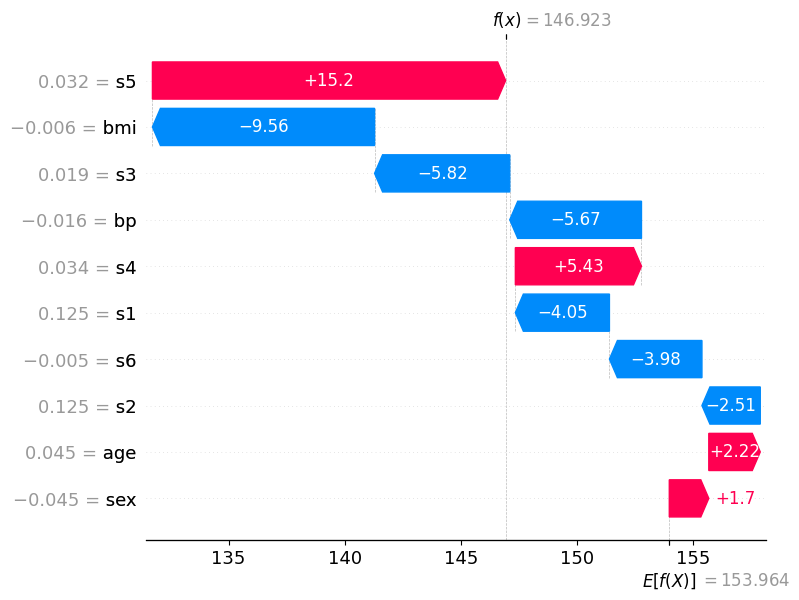

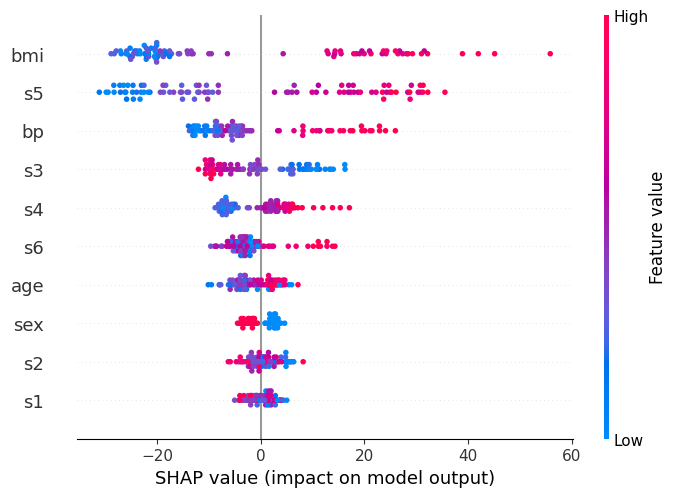

=== MDI Ranking ===
bmi    0.250692
s5     0.202246
bp     0.119689
s3     0.084039
s6     0.083752
dtype: float64

=== SHAP Ranking ===
bmi    22.008288
s5     19.684373
bp      9.868147
s3      7.109236
s4      5.116094
dtype: float64



In [7]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 4: SHAP setup and TreeExplainer
# -----------------------------------------------------------

# Install SHAP if needed
# !pip install shap
import shap


explainer = shap.TreeExplainer(rf_tuned)


shap_values = explainer(X_test)


# 1. Waterfall plot


sample_idx = 0

print(f"Explaining observation #{sample_idx}")
shap.plots.waterfall(shap_values[sample_idx])


# 2. Beeswarm plot


shap.plots.beeswarm(shap_values)

# 3. Compare MDI vs SHAP ranking



mdi_importance = pd.Series(
    rf_tuned.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

shap_importance = pd.Series(
    np.abs(shap_values.values).mean(axis=0),
    index=X.columns
).sort_values(ascending=False)

print("=== MDI Ranking ===")
print(mdi_importance.head(5))
print()

print("=== SHAP Ranking ===")
print(shap_importance.head(5))
print()
# Create SHAP explainer for the tuned RF
# explainer = shap.TreeExplainer(best_rf)  # use your tuned RF from Part 3
# shap_values = explainer.shap_values(X_test)

# 1. Waterfall plot for 3 observations: one high-value, one low-value, one surprising
# shap.plots.waterfall(shap.Explanation(values=shap_values[0], base_values=explainer.expected_value, data=X_test.iloc[0]))

# 2. Beeswarm plot (global view)
# shap.plots.beeswarm(shap.Explanation(values=shap_values, base_values=explainer.expected_value, data=X_test))

# 3. Compare MDI ranking vs SHAP ranking \u2014 do they agree? Where do they diverge?

**SHAP Interpretation (write as a .py module)**

Create a reusable shap_analysis.py module with:



*   explain_prediction(model, X, idx) → returns SHAP waterfall for observation idx
*   global_importance(model, X) → returns SHAP beeswarm plot
*   compare_importance(model, X, y) → returns side-by-side MDI vs SHAP ranking


Include docstrings and type hints. This is a portfolio artifact.


**AI-Assisted Expansion: SHAP Dashboard + Reusable Module**

The Generative AI Policy: Foundations First, Expansion Second. You have now established manual mastery over decision trees, random forests, hyperparameter tuning, feature importance, and SHAP explanations. You are now authorized to operate under the "Co-Pilot Rule."

**Your Expansion Task (5200 — Advanced)**

Build TWO artifacts:

Artifact 1: src/shap_utils.py module with:

* explain_prediction(model, X, idx) → SHAP waterfall plot
* global_importance(model, X) → SHAP beeswarm plot
* compare_importance(model, X, y) → side-by-side MDI vs SHAP ranking
* Full docstrings, type hints, and error handling

Artifact 2: Interactive Streamlit app that lets the user:

1. Adjust n_estimators (1-500) and max_features (1-8) with sliders
2. See SHAP waterfall + beeswarm plots update with each parameter change
3. Compare RF vs Ridge vs GBR performance as hyperparameters change
4. Toggle between MDI, permutation, and SHAP importance rankings

**P.R.I.M.E. Prompt**

In [8]:
"""
Reusable SHAP utilities for tree-based regression models.

This module provides helper functions to:
1. Explain an individual prediction with a SHAP waterfall plot
2. Show global SHAP importance with a beeswarm plot
3. Compare MDI importance with SHAP importance side by side

Designed for RandomForestRegressor / GradientBoostingRegressor style models.
"""

from __future__ import annotations

from typing import Any, Tuple

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt


def _validate_inputs(model: Any, X: pd.DataFrame) -> None:
    """
    Validate the model and feature matrix.

    Parameters
    ----------
    model : Any
        A fitted tree-based model with either feature_importances_ or SHAP-compatible structure.
    X : pd.DataFrame
        Feature matrix.

    Raises
    ------
    TypeError
        If X is not a pandas DataFrame.
    ValueError
        If X is empty.
    AttributeError
        If the model does not appear to be fitted or compatible.
    """
    if not isinstance(X, pd.DataFrame):
        raise TypeError("X must be a pandas DataFrame.")

    if X.empty:
        raise ValueError("X is empty.")

    if not hasattr(model, "predict"):
        raise AttributeError("Model must have a predict method.")

    # TreeExplainer supports many tree models, but we at least check predict exists.
    # compare_importance also needs feature_importances_.
    return


def _get_shap_explainer(model: Any) -> shap.TreeExplainer:
    """
    Create a SHAP TreeExplainer for the fitted model.

    Parameters
    ----------
    model : Any
        Fitted tree-based model.

    Returns
    -------
    shap.TreeExplainer
        SHAP explainer object.
    """
    return shap.TreeExplainer(model)


def explain_prediction(model: Any, X: pd.DataFrame, idx: int) -> shap.Explanation:
    """
    Generate a SHAP waterfall plot for one observation.

    Parameters
    ----------
    model : Any
        Fitted tree-based model.
    X : pd.DataFrame
        Feature matrix.
    idx : int
        Row index of the observation to explain.

    Returns
    -------
    shap.Explanation
        SHAP explanation for the selected observation.

    Raises
    ------
    IndexError
        If idx is outside the valid range.
    """
    _validate_inputs(model, X)

    if idx < 0 or idx >= len(X):
        raise IndexError(f"idx={idx} is out of bounds for X with length {len(X)}.")

    explainer = _get_shap_explainer(model)
    shap_values = explainer(X)

    # Waterfall plot for one row
    shap.plots.waterfall(shap_values[idx], show=True)
    return shap_values[idx]


def global_importance(model: Any, X: pd.DataFrame) -> shap.Explanation:
    """
    Generate a SHAP beeswarm plot for global feature importance.

    Parameters
    ----------
    model : Any
        Fitted tree-based model.
    X : pd.DataFrame
        Feature matrix.

    Returns
    -------
    shap.Explanation
        SHAP explanation object for the full dataset.
    """
    _validate_inputs(model, X)

    explainer = _get_shap_explainer(model)
    shap_values = explainer(X)

    shap.plots.beeswarm(shap_values, show=True)
    return shap_values


def compare_importance(
    model: Any,
    X: pd.DataFrame,
    y: pd.Series | np.ndarray | None = None
) -> Tuple[pd.DataFrame, plt.Figure]:
    """
    Compare MDI importance and SHAP importance side by side.

    Parameters
    ----------
    model : Any
        Fitted tree-based model with feature_importances_ attribute.
    X : pd.DataFrame
        Feature matrix.
    y : pd.Series | np.ndarray | None, optional
        Included for interface consistency. Not required for the comparison itself.

    Returns
    -------
    tuple[pd.DataFrame, matplotlib.figure.Figure]
        A DataFrame with MDI rank and SHAP rank, and the comparison figure.

    Raises
    ------
    AttributeError
        If the model does not have feature_importances_.
    """
    _validate_inputs(model, X)

    if not hasattr(model, "feature_importances_"):
        raise AttributeError(
            "Model must have feature_importances_ to compare MDI vs SHAP importance."
        )

    explainer = _get_shap_explainer(model)
    shap_values = explainer(X)

    # MDI importance: based on impurity reduction in tree splits
    mdi = pd.Series(model.feature_importances_, index=X.columns, name="MDI").sort_values(ascending=False)

    # SHAP importance: average absolute contribution across observations
    shap_imp = pd.Series(
        np.abs(shap_values.values).mean(axis=0),
        index=X.columns,
        name="SHAP"
    ).sort_values(ascending=False)

    comparison = pd.concat([mdi, shap_imp], axis=1).fillna(0)
    comparison["MDI_rank"] = comparison["MDI"].rank(ascending=False, method="dense").astype(int)
    comparison["SHAP_rank"] = comparison["SHAP"].rank(ascending=False, method="dense").astype(int)
    comparison = comparison.sort_values("SHAP", ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    mdi.sort_values(ascending=True).plot(kind="barh", ax=axes[0], title="MDI Importance")
    shap_imp.sort_values(ascending=True).plot(kind="barh", ax=axes[1], title="SHAP Importance")

    axes[0].set_xlabel("Importance")
    axes[1].set_xlabel("Mean |SHAP value|")

    plt.tight_layout()
    return comparison, fig
